# 00. Project Map for `codex_notebooks`

This notebook defines the rebuilt project story before we dive into EDA or models.

**By the end of this notebook you should understand**
- what the forecasting task actually is
- why weighted skill, chronology, and split design matter
- which series are used as the 4 main representatives
- what the small broader benchmark is doing


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from codex_notebooks.support import (
    CODEX_DIR,
    apply_plot_style,
    build_codex_artifacts,
    export_figure,
    load_artifact,
    load_json_artifact,
)

apply_plot_style()
build_codex_artifacts(force=False, verbose=True)

overview = load_json_artifact('overview.json')
chosen = load_artifact('chosen_manifest.parquet')
benchmark = load_artifact('benchmark_manifest.parquet')


Codex artifacts already available in /Users/jeetraj/Desktop/Everything/DAIICT/Sem_6/Applied_Forecasting_Methods/Project/data/processed/codex


## 1. Project scope

The rebuilt notebook layer is intentionally narrower than the repo README. It focuses on:
- the panel forecasting problem itself
- EDA that changes model choice
- a clean classical study
- a clean deep-sequence study

It does **not** try to retell the full global-ML and ensemble pipeline here.


In [2]:
overview_df = pd.DataFrame(
    {
        'Metric': [
            'Train rows',
            'Test rows',
            'Features',
            'Codes',
            'Train sub-codes',
            'Test sub-codes',
            'Horizons',
            'Train ts range',
            'Test ts range',
        ],
        'Value': [
            f"{overview['train_rows']:,}",
            f"{overview['test_rows']:,}",
            overview['feature_count'],
            overview['codes'],
            overview['sub_codes_train'],
            overview['sub_codes_test'],
            ', '.join(map(str, overview['horizons'])),
            f"{overview['train_ts_min']}–{overview['train_ts_max']}",
            f"{overview['test_ts_min']}–{overview['test_ts_max']}",
        ],
    }
)
display(overview_df)


,Metric,Value
0,Train rows,"5,337,414"
1,Test rows,"1,447,107"
2,Features,86
3,Codes,23
4,Train sub-codes,180
5,Test sub-codes,47
6,Horizons,"1, 3, 10, 25"
7,Train ts range,1–3601
8,Test ts range,3602–4376


## 2. Primary metric

The project still uses the weighted skill score:

\[
\text{skill} = \sqrt{1 - \operatorname{clip}_{0,1}
\left(\frac{\sum_i w_i (y_i - \hat y_i)^2}{\sum_i w_i y_i^2}\right)}
\]

**Interpretation**
- higher is better
- `1.0` is perfect
- weighting is central, not optional


## 3. Unified split policy

The old notebook mismatch is removed here. Classical and deep notebooks will use the same per-series chronological split rule.

**Rule**
- first 80% of each selected series = training
- last 20% = validation
- minimum series length = 120
- minimum validation length = 24


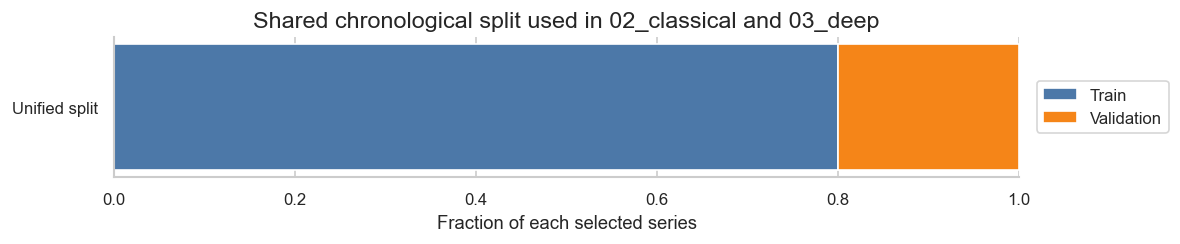

In [3]:
split = overview['split_policy']

fig, ax = plt.subplots(figsize=(10, 2.2))
ax.barh(['Unified split'], [split['train_fraction']], color='#4C78A8', label='Train')
ax.barh(['Unified split'], [1 - split['train_fraction']], left=[split['train_fraction']], color='#F58518', label='Validation')
ax.set_xlim(0, 1)
ax.set_xlabel('Fraction of each selected series')
ax.set_title('Shared chronological split used in 02_classical and 03_deep')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))
fig.tight_layout()
export_figure(fig, '00_unified_split_policy.png')
plt.show()


**Final deck figure:** `00_unified_split_policy.png`


## 4. Two evidence layers

The rebuilt project uses:
- **4 representatives** for high-clarity teaching
- **1 fixed broader benchmark** so conclusions are not only anecdotal


In [4]:
display(chosen[['series_id', 'reason', 'length', 'total_weight', 'target_std']])
display(benchmark[['series_id', 'horizon', 'benchmark_band', 'length', 'total_weight', 'target_std']])


,series_id,reason,length,total_weight,target_std
0,SJZP0OVU__OYJGNSQK__NQ58FVQM__H25,highest total weight,156,4.349747e+10,0.000394
1,X9BZ68VQ__OYJGNSQK__DPPUO5X2__H1,longest history,212,9.060035e+02,2.641558
2,SJZP0OVU__OYJGNSQK__NQ58FVQM__H1,most stable,170,3.869062e+10,0.000139
3,W4S29LF4__KL66VIS3__PHHHVYZI__H25,most volatile,162,4.562944e-01,296.760011


,series_id,horizon,benchmark_band,length,total_weight,target_std
0,660DZME0__J7UUOGYG__PHHHVYZI__H1,1,H1_q25,190,4.072036e+03,0.708796
1,MRV5UON2__OYJGNSQK__NQ58FVQM__H1,1,H1_q75,195,1.802742e+07,0.012439
2,660DZME0__FDIGHKLX__V8BKY1IV__H3,3,H3_q25,197,3.064603e+03,0.942666
3,K8I5QG74__ZCXVEKMJ__NQ58FVQM__H3,3,H3_q75,175,1.498141e+07,0.017008
4,X9BZ68VQ__9R4MOCGO__PZ9S1Z4V__H10,10,H10_q25,121,2.506899e+03,2.010633
5,1HEMHZK2__YLX4X4O9__PHHHVYZI__H10,10,H10_q75,134,1.147596e+07,0.032550
6,OSJL3A7Y__OVZL1F3B__PHHHVYZI__H25,25,H25_q25,183,2.213125e+03,4.683543
7,K8I5QG74__H9GNMAHM__PHHHVYZI__H25,25,H25_q75,171,8.505613e+06,0.063617


## 5. What we learned

- the codex notebooks will teach a narrower but cleaner project story
- split design is now unified before any model comparison
- the old 4 anchor series are preserved as the main explanatory devices
- the broader benchmark gives us a small reality check beyond those 4 series

## What changes next

`01_eda.ipynb` will justify the model choices before any forecasting results are shown.
